In [25]:
#Librerias base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Creamos el entorno para acceder a los archivos del drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
#Cargamos el archivo a analizar

ruta_entrada = '/content/drive/MyDrive/1. Proyectos/e. Proyecto Predicción de enfermedades crónicas en Bucaramanga/Datasets/tabla_final_modelos.csv'

df = pd.read_csv(ruta_entrada)
df.head(7)

,Modelo,Umbral,Accuracy,Precision,Recall,F1,ROC-AUC,TP,FP,FN,TN,Training Time (s),Inference Time (s),Mejor F1 promedio (CV Realista)
0,XGBoost,0.7,0.7330,0.7772,0.2649,0.3951,0.6759,3045,873,8451,22556,1504.14,0.0594,0.5742
1,XGBoost,0.6,0.7373,0.7186,0.3319,0.4541,0.6759,3816,1494,7680,21935,1504.14,0.0594,0.5742
2,XGBoost,0.5,0.4613,0.3714,0.9188,0.5289,0.6759,10562,17880,934,5549,1504.14,0.0594,0.5742
3,XGBoost,0.4,0.4451,0.3682,0.9582,0.5320,0.6759,11016,18899,480,4530,1504.14,0.0594,0.5742
4,XGBoost,0.3,0.4109,0.3563,0.9796,0.5226,0.6759,11262,20342,234,3087,1504.14,0.0594,0.5742
5,XGBoost,0.2,0.3839,0.3475,0.9930,0.5148,0.6759,11415,21435,81,1994,1504.14,0.0594,0.5742
6,XGBoost,0.1,0.3508,0.3363,0.9989,0.5032,0.6759,11483,22661,13,768,1504.14,0.0594,0.5742


In [27]:
# 2. Mostrar la tabla formateada para el artículo
print("### Tabla 3. Comparativa de Desempeño de Modelos (Umbral 0.5) ###")
print(df.to_string(index=False))

### Tabla 3. Comparativa de Desempeño de Modelos (Umbral 0.5) ###
            Modelo  Umbral  Accuracy  Precision  Recall     F1  ROC-AUC    TP    FP    FN    TN  Training Time (s)  Inference Time (s)  Mejor F1 promedio (CV Realista)
           XGBoost     0.7    0.7330     0.7772  0.2649 0.3951   0.6759  3045   873  8451 22556            1504.14              0.0594                           0.5742
           XGBoost     0.6    0.7373     0.7186  0.3319 0.4541   0.6759  3816  1494  7680 21935            1504.14              0.0594                           0.5742
           XGBoost     0.5    0.4613     0.3714  0.9188 0.5289   0.6759 10562 17880   934  5549            1504.14              0.0594                           0.5742
           XGBoost     0.4    0.4451     0.3682  0.9582 0.5320   0.6759 11016 18899   480  4530            1504.14              0.0594                           0.5742
           XGBoost     0.3    0.4109     0.3563  0.9796 0.5226   0.6759 11262 20342   234  308

In [28]:
# 3. Configuración visual para la publicación
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

<Figure size 1200x700 with 0 Axes>

# 4.3 Evaluación comparativa de modelos

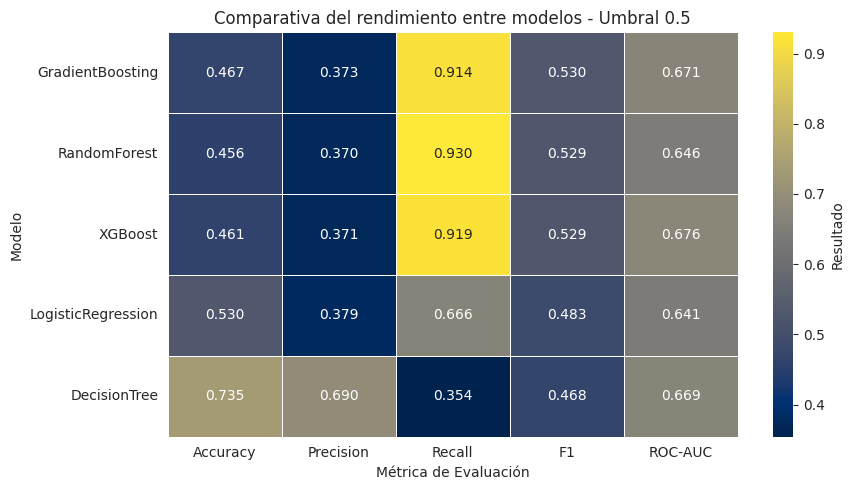

In [29]:
metricas = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

df_05 = df[df['Umbral'] == 0.5].copy()
df_05 = df_05.sort_values('F1', ascending=False)

data = df_05.set_index('Modelo')[metricas]

plt.figure(figsize=(9, 5))
sns.heatmap(
    data,
    annot=True,
    fmt=".3f",
    cmap="cividis",
    linewidths=0.4,
    cbar_kws={'label': 'Resultado'}
)

plt.xlabel("Métrica de Evaluación")
plt.ylabel("Modelo")
plt.title("Comparativa del rendimiento entre modelos - Umbral 0.5")
plt.tight_layout()


ruta = "/content/drive/MyDrive/1. Proyectos/e. Proyecto Predicción de enfermedades crónicas en Bucaramanga/Imágenes/heatmap_umbral_05.png"

plt.savefig(
    ruta,
    dpi=300,              # estándar revista científica
    bbox_inches="tight"
)


plt.show()



/tmp/ipython-input-4190413383.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("cividis")


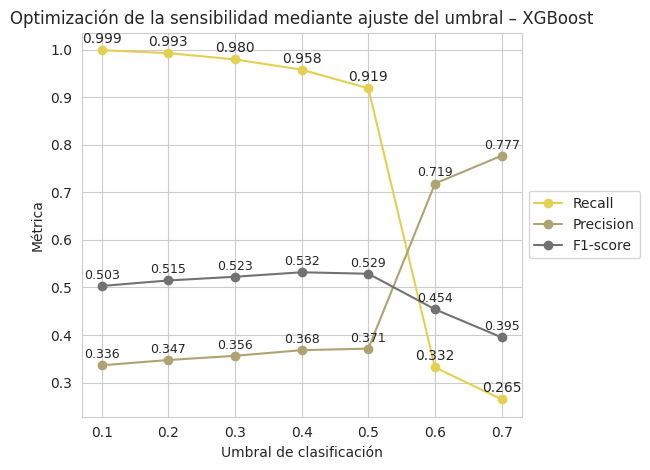

In [34]:
import matplotlib.cm as cm

# Filtrar modelo óptimo
df_xgb = df[df['Modelo'] == 'XGBoost'].sort_values("Umbral")

# Colormap consistente con el heatmap
cmap = cm.get_cmap("cividis")

# Asignación de colores desde el cmap
color_recall = cmap(0.9)      # valores altos → amarillo (sensibilidad)
color_precision = cmap(0.7)   # valores medios → verde/gris
color_f1 = cmap(0.45)         # valores medio-bajos → azul/gris

plt.figure()

plt.plot(
    df_xgb["Umbral"],
    df_xgb["Recall"],
    marker='o',
    color=color_recall,
    label="Recall"
)

plt.plot(
    df_xgb["Umbral"],
    df_xgb["Precision"],
    marker='o',
    color=color_precision,
    label="Precision"
)

plt.plot(
    df_xgb["Umbral"],
    df_xgb["F1"],
    marker='o',
    color=color_f1,
    label="F1-score"
)

# Etiquetas SOLO para Recall (mismo color)
for x, y in zip(df_xgb["Umbral"], df_xgb["Precision"]):
    plt.text(x, y + 0.015, f"{y:.3f}", ha='center', fontsize=9)

# Etiquetas SOLO para Recall (mismo color)
for x, y in zip(df_xgb["Umbral"], df_xgb["Recall"]):
    plt.text(x, y + 0.015, f"{y:.3f}", ha='center', fontsize=10)

# Etiquetas SOLO para Recall (mismo color)
for x, y in zip(df_xgb["Umbral"], df_xgb["F1"]):
    plt.text(x, y + 0.015, f"{y:.3f}", ha='center', fontsize=9)


plt.xlabel("Umbral de clasificación")
plt.ylabel("Métrica")
plt.title("Optimización de la sensibilidad mediante ajuste del umbral – XGBoost")

# Leyenda fuera del gráfico
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()

ruta = "/content/drive/MyDrive/1. Proyectos/e. Proyecto Predicción de enfermedades crónicas en Bucaramanga/Imágenes/xgboost_umbrales"

plt.savefig(
    ruta,
    dpi=300,              # estándar revista científica
    bbox_inches="tight"
)

plt.show()


In [31]:
df

,Modelo,Umbral,Accuracy,Precision,Recall,F1,ROC-AUC,TP,FP,FN,TN,Training Time (s),Inference Time (s),Mejor F1 promedio (CV Realista)
0,XGBoost,0.7,0.7330,0.7772,0.2649,0.3951,0.6759,3045,873,8451,22556,1504.14,0.0594,0.5742
1,XGBoost,0.6,0.7373,0.7186,0.3319,0.4541,0.6759,3816,1494,7680,21935,1504.14,0.0594,0.5742
2,XGBoost,0.5,0.4613,0.3714,0.9188,0.5289,0.6759,10562,17880,934,5549,1504.14,0.0594,0.5742
3,XGBoost,0.4,0.4451,0.3682,0.9582,0.5320,0.6759,11016,18899,480,4530,1504.14,0.0594,0.5742
4,XGBoost,0.3,0.4109,0.3563,0.9796,0.5226,0.6759,11262,20342,234,3087,1504.14,0.0594,0.5742
5,XGBoost,0.2,0.3839,0.3475,0.9930,0.5148,0.6759,11415,21435,81,1994,1504.14,0.0594,0.5742
6,XGBoost,0.1,0.3508,0.3363,0.9989,0.5032,0.6759,11483,22661,13,768,1504.14,0.0594,0.5742
7,GradientBoosting,0.7,0.7390,0.7518,0.3091,0.4380,0.6711,3553,1173,7943,22256,2752.09,0.0399,0.5697
8,GradientBoosting,0.6,0.7394,0.7292,0.3316,0.4559,0.6711,3812,1416,7684,22013,2752.09,0.0399,0.5697
9,GradientBoosting,0.5,0.4665,0.3732,0.9140,0.5300,0.6711,10507,17645,989,5784,2752.09,0.0399,0.5697


In [32]:
#Cargamos el archivo a analizar la importancia de variables

ruta_entrada_fi = '/content/drive/MyDrive/1. Proyectos/e. Proyecto Predicción de enfermedades crónicas en Bucaramanga/Datasets/tabla_final_importancia_variables.csv'

df_fi = pd.read_csv(ruta_entrada_fi)
df_fi

,Modelo,Tipo_Metrica,Variable,Valor_Impacto,Valor_Absoluto
0,LogisticRegression,Coeficiente,artritis,-2.536510,2.536510
1,LogisticRegression,Coeficiente,asma,-2.385305,2.385305
2,LogisticRegression,Coeficiente,huerfanas_hemofilias_y_otras,-2.150506,2.150506
3,LogisticRegression,Coeficiente,ciclo_de_vida_PERSONA MAYOR,1.970266,1.970266
4,LogisticRegression,Coeficiente,trasplantados,-1.756721,1.756721
...,...,...,...,...,...
145,XGBoost,Importancia,tipo_erc_limpio_Estadio V,0.000000,0.000000
146,XGBoost,Importancia,erc_trr_limpio_Recibe TRR (no especificada),0.000000,0.000000
147,XGBoost,Importancia,erc_trr_limpio_Prediálisis,0.000000,0.000000
148,XGBoost,Importancia,regimen_E,0.000000,0.000000


/tmp/ipython-input-2433807794.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Impacto_Pct', y='Variable', data=df_top, palette='cividis')


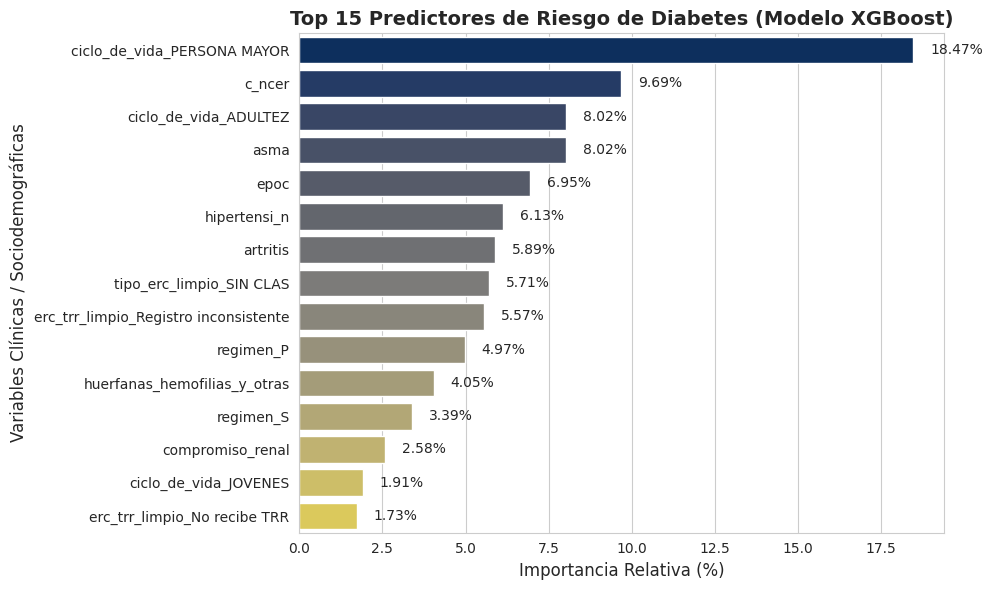

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar tus datos reales
df_xgb = df_fi.copy()


# 2. Filtrar SOLO para XGBoost (tu mejor modelo)
df_xgb = df_real[df_real['Modelo'] == 'XGBoost'].copy()

# 3. Convertir a porcentaje para mejor visualización
df_xgb['Impacto_Pct'] = df_xgb['Valor_Impacto'] * 100

# 4. Seleccionar el Top 10 para que el gráfico no sea ruidoso
df_top = df_xgb.sort_values(by='Impacto_Pct', ascending=False).head(15)

# 5. Crear el gráfico profesional
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x='Impacto_Pct', y='Variable', data=df_top, palette='cividis')

plt.title('Top 15 Predictores de Riesgo de Diabetes (Modelo XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Importancia Relativa (%)', fontsize=12)
plt.ylabel('Variables Clínicas / Sociodemográficas', fontsize=12)

# Añadir etiquetas con los valores exactos
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.5, p.get_y() + p.get_height()/2, f'{width:.2f}%', va='center', fontsize=10)

plt.tight_layout()
ruta_fi = "/content/drive/MyDrive/1. Proyectos/e. Proyecto Predicción de enfermedades crónicas en Bucaramanga/Imágenes/xgboost_fi"

plt.savefig(
    ruta_fi,
    dpi=300,              # estándar revista científica
    bbox_inches="tight"
)


plt.show()